# FOMC-Dated Swap Analytics

**Part 1:** SDR flow analytics â€” which meetings attract volume, activity timing, trade characteristics.  
**Part 2:** Implied rate extraction â€” meeting-by-meeting implied SOFR, cut/hike probabilities, FOMC curve, calendar spreads.

FOMC-dated swaps are OIS contracts whose effective/maturity dates align with FOMC meeting boundaries.
Each meeting period spans from one FOMC effective date to the next. A swap spanning this period
prices the expected average overnight rate for that specific meeting window.

In [1]:
import nest_asyncio
nest_asyncio.apply()

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import _usd_swaps_common as sdr

sdr.notebook_setup()

# --- Parameters ---
START = datetime.datetime(2025, 4, 10, tzinfo=datetime.timezone.utc)
END = datetime.datetime(2026, 4, 10, 23, 59, 59, tzinfo=datetime.timezone.utc)
CACHE_PATH = sdr.DEFAULT_CACHE_PATH
CURVE_NAME = "USD-SOFR-1D"

# Current effective SOFR rate (update as needed, or pull from FRED)
CURRENT_SOFR = 4.30 / 100  # 4.30% as decimal

ModuleNotFoundError: No module named 'SDRUtils'

In [2]:
from Query.IRSwaps._CENTRAL_BANK_DATES import _CENTRAL_BANK_DATES

# Each entry: label -> (effective_date, maturity_date)
# effective_date = FOMC meeting date, maturity_date = next FOMC meeting date
fomc_schedule_raw = _CENTRAL_BANK_DATES.get("USD-SOFR-1D", {})

# Build clean schedule DataFrame
fomc_meetings = []
for label, (eff, mat) in sorted(fomc_schedule_raw.items(), key=lambda x: x[1][0]):
    fomc_meetings.append({
        "meeting_label": label,
        "effective_date": eff,
        "maturity_date": mat,
        "period_days": (mat - eff).days,
    })

fomc_df = pd.DataFrame(fomc_meetings)
fomc_df["effective_date"] = pd.to_datetime(fomc_df["effective_date"])
fomc_df["maturity_date"] = pd.to_datetime(fomc_df["maturity_date"])

# Filter to analysis window with some lookahead
schedule_start = pd.Timestamp(START).tz_localize(None) - pd.Timedelta(days=90)
schedule_end = pd.Timestamp(END).tz_localize(None) + pd.Timedelta(days=365)
fomc_df = fomc_df[
    (fomc_df["effective_date"] >= schedule_start) &
    (fomc_df["effective_date"] <= schedule_end)
].reset_index(drop=True)

# Build lookup: effective_date -> meeting_label
eff_to_label = dict(zip(fomc_df["effective_date"].dt.date, fomc_df["meeting_label"]))
mat_to_label = dict(zip(fomc_df["maturity_date"].dt.date, fomc_df["meeting_label"]))

print(f"FOMC meetings in window: {len(fomc_df)}")
display(fomc_df.head(15))

ModuleNotFoundError: No module named 'Query'

In [3]:
df = sdr.load_usd_swaps(START, END, cache_path=CACHE_PATH)
df = sdr.filter_new_risk(df)

# Filter to FOMC-dated trades
if df.empty:
    print("WARNING: No SDR trade data available. Part 1 (flow analytics) will be skipped.")
    print("Part 2 (curve-based implied rates) will still run.")
    fomc_trades = pd.DataFrame()
else:
    fomc_trades = df[df["special_tenor_type"].astype(str) == "FOMC"].copy()

# Assign meeting_label based on expiration_date matching a meeting maturity
# FOMC swaps expire on the next meeting date (maturity of the meeting period)
def assign_meeting_label(row):
    exp = pd.to_datetime(row.get("expiration_date"))
    eff = pd.to_datetime(row.get("effective_date"))
    if pd.notna(exp):
        exp_date = exp.date() if hasattr(exp, "date") else exp
        # Check if expiration matches any meeting's maturity (= swap covers that meeting period)
        label = mat_to_label.get(exp_date)
        if label:
            return label
    if pd.notna(eff):
        eff_date = eff.date() if hasattr(eff, "date") else eff
        label = eff_to_label.get(eff_date)
        if label:
            return label
    return "UNKNOWN"

if not fomc_trades.empty:
    fomc_trades["meeting_label"] = fomc_trades.apply(assign_meeting_label, axis=1)
    fomc_trades = fomc_trades[fomc_trades["meeting_label"] != "UNKNOWN"]

    # Merge in meeting schedule info
    fomc_trades = fomc_trades.merge(
        fomc_df[["meeting_label", "effective_date", "maturity_date", "period_days"]].rename(
            columns={"effective_date": "meeting_eff", "maturity_date": "meeting_mat"}
        ),
        on="meeting_label",
        how="left",
    )

n_total = len(df)
print(f"Total new-risk trades: {n_total:,}")
print(f"FOMC-dated trades: {len(fomc_trades):,} ({len(fomc_trades)/max(n_total,1)*100:.2f}%)")
if not fomc_trades.empty:
    print(f"Unique meetings traded: {fomc_trades['meeting_label'].nunique()}")
    print(f"DV01: {sdr.format_dv01(fomc_trades['dv01'].sum())}")

NameError: name 'sdr' is not defined

---
# Part 1: Flow Analytics

## 1. Volume by FOMC Meeting
Which meetings attract the most positioning? DV01 per meeting label.

In [4]:
if not fomc_trades.empty:
    meeting_dv01 = fomc_trades.groupby("meeting_label").agg(
        trade_count=("dv01", "size"),
        total_dv01=("dv01", "sum"),
        total_notional=("notional", "sum"),
        avg_rate=("fixed_rate", lambda x: pd.to_numeric(x, errors="coerce").mean()),
    ).sort_index()
    
    # Sort by meeting date order
    label_order = fomc_df["meeting_label"].tolist()
    meeting_dv01 = meeting_dv01.reindex([l for l in label_order if l in meeting_dv01.index])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # DV01 by meeting
    axes[0].bar(range(len(meeting_dv01)), meeting_dv01["total_dv01"], color="#4C78A8", alpha=0.8)
    axes[0].set_ylabel("DV01 ($)")
    axes[0].set_title("DV01 by FOMC Meeting")
    
    # Trade count by meeting
    axes[1].bar(range(len(meeting_dv01)), meeting_dv01["trade_count"], color="#F58518", alpha=0.8)
    axes[1].set_ylabel("Trade Count")
    axes[1].set_xticks(range(len(meeting_dv01)))
    axes[1].set_xticklabels(meeting_dv01.index, rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()
    
    print("\nVolume by Meeting:")
    display(meeting_dv01.round(2))
else:
    print("Skipped: no FOMC-dated trades in SDR data.")

NameError: name 'fomc_trades' is not defined

In [5]:
if not fomc_trades.empty:
    fomc_daily = fomc_trades.groupby("execution_date")["dv01"].sum()
    fomc_daily.index = pd.to_datetime(fomc_daily.index)
    
    # Meeting dates as vertical lines
    fomc_eff_dates = fomc_df["effective_date"].tolist()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(fomc_daily.index, fomc_daily.values, alpha=0.6, color="#4C78A8", width=1)
    
    for fd in fomc_eff_dates:
        if pd.Timestamp(START).tz_localize(None) <= fd <= pd.Timestamp(END).tz_localize(None):
            ax.axvline(fd, color="red", linestyle="--", alpha=0.4, linewidth=0.8)
    
    ax.set_title("Daily FOMC-Dated Swap DV01 (red lines = FOMC meetings)")
    ax.set_ylabel("DV01 ($)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no FOMC-dated trades in SDR data.")

NameError: name 'fomc_trades' is not defined

In [6]:
if not fomc_trades.empty:
    # Split by proximity: next 1-3 meetings vs 4+ meetings from trade date
    def meetings_ahead(row):
        exec_date = pd.to_datetime(row["execution_timestamp"]).date()
        meeting_eff = row["meeting_eff"]
        if pd.isna(meeting_eff):
            return 99
        meeting_date = meeting_eff.date() if hasattr(meeting_eff, "date") else meeting_eff
        # Count how many meetings are between exec_date and meeting_date
        upcoming = [m for m in fomc_df["effective_date"].dt.date if m >= exec_date]
        try:
            rank = sorted(upcoming).index(meeting_date) + 1
        except ValueError:
            rank = 99
        return rank
    
    fomc_trades["meetings_ahead"] = fomc_trades.apply(meetings_ahead, axis=1)
    fomc_trades["proximity"] = fomc_trades["meetings_ahead"].apply(
        lambda x: "Near (1-3)" if x <= 3 else ("Mid (4-6)" if x <= 6 else "Far (7+)")
    )
    
    prox_dv01 = fomc_trades.groupby("proximity")["dv01"].sum()
    fig, ax = plt.subplots(figsize=(8, 5))
    prox_dv01.plot.pie(ax=ax, autopct="%1.1f%%", colors=["#4C78A8", "#F58518", "#E45756"], startangle=90)
    ax.set_ylabel("")
    ax.set_title("FOMC Swap DV01: Near vs Mid vs Far Meetings")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no FOMC-dated trades in SDR data.")

NameError: name 'fomc_trades' is not defined

## 2. Activity Timing Around Meetings
How does FOMC-swap trading evolve in the T-10..T+2 window around each meeting?

In [7]:
if not fomc_trades.empty:
    all_daily = df.groupby("execution_date")["dv01"].sum()
    all_daily.index = pd.to_datetime(all_daily.index)
    
    def meeting_window_profile(meeting_dates, window=10):
        """Average FOMC-dated DV01 in T-window..T+2 around meetings."""
        profiles = []
        for md in meeting_dates:
            md_ts = pd.Timestamp(md)
            for offset in range(-window, 3):
                target = md_ts + pd.Timedelta(days=offset)
                # Find the fomc-dated trades on this date for THIS meeting's label
                label = eff_to_label.get(md.date() if hasattr(md, "date") else md)
                if label is None:
                    continue
                day_trades = fomc_trades[
                    (pd.to_datetime(fomc_trades["execution_date"]) == target) &
                    (fomc_trades["meeting_label"] == label)
                ]
                val = day_trades["dv01"].sum() if not day_trades.empty else 0
                profiles.append({"offset": offset, "dv01": val, "meeting": label})
        
        if not profiles:
            return pd.Series(dtype=float)
        return pd.DataFrame(profiles).groupby("offset")["dv01"].mean()
    
    # Meetings within our trade data window
    meetings_in_range = fomc_df[
        (fomc_df["effective_date"] >= pd.Timestamp(START).tz_localize(None)) &
        (fomc_df["effective_date"] <= pd.Timestamp(END).tz_localize(None))
    ]["effective_date"]
    
    avg_profile = meeting_window_profile(meetings_in_range.tolist())
    
    if not avg_profile.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        colors = ["#E45756" if x == 0 else "#4C78A8" for x in avg_profile.index]
        ax.bar(avg_profile.index, avg_profile.values, color=colors, alpha=0.8)
        ax.axvline(0, color="red", linestyle="--", alpha=0.5, linewidth=2)
        ax.set_title(f"Average FOMC-Swap DV01 Around Meeting Dates (n={len(meetings_in_range)})")
        ax.set_xlabel("Business Days from FOMC Meeting")
        ax.set_ylabel("Avg DV01 ($)")
        plt.tight_layout()
        plt.show()
else:
    print("Skipped: no FOMC-dated trades in SDR data.")

NameError: name 'fomc_trades' is not defined

## 3. FOMC Swap Characteristics
Notional distribution, package detection, block analysis.

In [8]:
if not fomc_trades.empty:
    # Compare FOMC vs non-FOMC swaps
    non_fomc = df[df["special_tenor_type"].astype(str) != "FOMC"]
    
    print("FOMC vs Non-FOMC Swap Characteristics:")
    print(f"  FOMC avg notional: ${fomc_trades['notional'].mean()/1e6:.1f}M")
    print(f"  Non-FOMC avg notional: ${non_fomc['notional'].mean()/1e6:.1f}M")
    print(f"  FOMC median notional: ${fomc_trades['notional'].median()/1e6:.1f}M")
    print(f"  Non-FOMC median notional: ${non_fomc['notional'].median()/1e6:.1f}M")
    
    # Package analysis
    pkg_dist = fomc_trades["package_type"].fillna("OUTRIGHT").value_counts()
    print(f"\nFOMC trade package types:")
    for pkg, count in pkg_dist.items():
        print(f"  {pkg}: {count} ({count/len(fomc_trades)*100:.1f}%)")
    
    # Block analysis
    if "block_trade_election_indicator" in fomc_trades.columns:
        blocks = fomc_trades[fomc_trades["block_trade_election_indicator"] == True]
        print(f"\nBlock trades: {len(blocks)} ({len(blocks)/len(fomc_trades)*100:.1f}%)")
    
    # FOMC curve detection (consecutive meeting trades at same timestamp)
    fomc_sorted = fomc_trades.sort_values("execution_timestamp")
    fomc_sorted["exec_ts_round"] = pd.to_datetime(fomc_sorted["execution_timestamp"]).dt.round("60s")
    
    potential_curves = fomc_sorted.groupby("exec_ts_round").filter(
        lambda g: g["meeting_label"].nunique() >= 2
    )
    n_curve_legs = len(potential_curves)
    print(f"\nPotential FOMC curve legs (2+ meetings within 60s): {n_curve_legs} trades")
else:
    print("Skipped: no FOMC-dated trades in SDR data.")

NameError: name 'fomc_trades' is not defined

---
# Part 2: Implied Rate Extraction

## 4. Meeting-by-Meeting Implied SOFR

Two methods:
- **SDR-based:** VWAP of FOMC-dated swap fixed rates (direct market observation)
- **Curve-based:** Price each meeting period off the SOFR curve via `IRSwapQuery`

In [9]:
if not fomc_trades.empty:
    # SDR VWAP: volume-weighted average fixed rate per meeting
    fomc_rates = fomc_trades[pd.to_numeric(fomc_trades["fixed_rate"], errors="coerce").notna()].copy()
    fomc_rates["fixed_rate"] = pd.to_numeric(fomc_rates["fixed_rate"])
    
    sdr_implied = fomc_rates.groupby("meeting_label").apply(
        lambda g: sdr.vwap(g, rate_col="fixed_rate", weight_col="dv01")
    ).rename("sdr_implied_rate")
    
    # Also compute the most recent day's VWAP per meeting
    recent_date = fomc_rates["execution_date"].max()
    recent_trades = fomc_rates[fomc_rates["execution_date"] == recent_date]
    sdr_latest = recent_trades.groupby("meeting_label").apply(
        lambda g: sdr.vwap(g, rate_col="fixed_rate", weight_col="dv01")
    ).rename("sdr_latest_rate")
    
    print(f"SDR implied rates extracted for {len(sdr_implied)} meetings")
    print(f"Latest trading date: {recent_date}")
else:
    sdr_implied = pd.Series(dtype=float, name="sdr_implied_rate")
    sdr_latest = pd.Series(dtype=float, name="sdr_latest_rate")
    recent_date = None
    print("No SDR trade data available for VWAP calculation.")

NameError: name 'fomc_trades' is not defined

In [10]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

# Get a curve for pricing
mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
# Use most recent business day (handles weekends/holidays)
import pandas as pd
today = datetime.date.today()
recent_bday = pd.Timestamp(today) - pd.tseries.offsets.BDay(0)
# If today is not a bday, go back one
if recent_bday.date() > today:
    recent_bday = pd.Timestamp(today) - pd.tseries.offsets.BDay(1)
pricing_date = recent_bday.date()
print(f"Pricing date: {pricing_date}")
curve = mdp.get_pricer(dict(curve_name=CURVE_NAME, timestamp=pricing_date))

# Price each upcoming meeting period
curve_implied = {}
pricing_errors = []

for _, row in fomc_df.iterrows():
    label = row["meeting_label"]
    eff = row["effective_date"].date()
    mat = row["maturity_date"].date()
    
    # Only price meetings not yet expired
    if mat < datetime.date.today():
        continue
    
    try:
        query = IRSwapQuery(
            curve=CURVE_NAME,
            effective_date=eff,
            maturity_date=mat,
            value=IRSwapValue.RATE,
        )
        package, _ = query.resolve_package(pricer_or_curve=curve)
        rate = curve.fair_rate(package[0])  # Returns decimal (e.g. 0.043 for 4.3%)
        curve_implied[label] = rate
    except Exception as e:
        pricing_errors.append((label, str(e)))

curve_implied_s = pd.Series(curve_implied, name="curve_implied_rate")

if pricing_errors:
    print(f"Pricing errors for {len(pricing_errors)} meetings:")
    for label, err in pricing_errors[:5]:
        print(f"  {label}: {err}")

print(f"Curve-implied rates extracted for {len(curve_implied_s)} meetings")

ModuleNotFoundError: No module named 'MDP'

In [11]:
# Merge all implied rates into meeting schedule
implied_df = fomc_df[["meeting_label", "effective_date", "maturity_date", "period_days"]].copy()
# Merge SDR VWAP rates (may be empty if no trade data)
if not sdr_implied.empty:
    sdr_df = sdr_implied.reset_index()
    sdr_df.columns = ["meeting_label", "sdr_implied_rate"]
    implied_df = implied_df.merge(sdr_df, on="meeting_label", how="left")
else:
    implied_df["sdr_implied_rate"] = np.nan

if not sdr_latest.empty:
    latest_df = sdr_latest.reset_index()
    latest_df.columns = ["meeting_label", "sdr_latest_rate"]
    implied_df = implied_df.merge(latest_df, on="meeting_label", how="left")
else:
    implied_df["sdr_latest_rate"] = np.nan

if not curve_implied_s.empty:
    curve_df = curve_implied_s.reset_index()
    curve_df.columns = ["meeting_label", "curve_implied_rate"]
    implied_df = implied_df.merge(curve_df, on="meeting_label", how="left")
else:
    implied_df["curve_implied_rate"] = np.nan

# Calculate implied move from current SOFR
implied_df["implied_move_bps"] = (implied_df["curve_implied_rate"] - CURRENT_SOFR) * 10_000

# Filter to meetings with at least one data point
implied_df = implied_df[
    implied_df["sdr_implied_rate"].notna() | implied_df["curve_implied_rate"].notna()
].reset_index(drop=True)

# Format for display
display_df = implied_df.copy()
for col in ["sdr_implied_rate", "sdr_latest_rate", "curve_implied_rate"]:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x*100:.3f}%" if pd.notna(x) else "N/A")
display_df["implied_move_bps"] = display_df["implied_move_bps"].apply(lambda x: f"{x:+.1f}" if pd.notna(x) else "N/A")

print(f"Meeting-by-Meeting Implied Rates (Current SOFR: {CURRENT_SOFR*100:.2f}%)")
display(display_df[["meeting_label", "effective_date", "maturity_date", "period_days",
                     "sdr_implied_rate", "sdr_latest_rate", "curve_implied_rate", "implied_move_bps"]])

NameError: name 'fomc_df' is not defined

## 5. Cut/Hike Probability Extraction

Standard formula:  
`P(25bp cut) = (current_rate - implied_forward_rate) / 0.0025`

Positive probability = market expects a cut. >100% = market expects >25bp cut.

In [12]:
BP25 = 0.0025  # 25 basis points

# Use curve-implied rates (more complete), fall back to SDR
implied_df["best_implied"] = implied_df["curve_implied_rate"].fillna(implied_df["sdr_implied_rate"])

# Probability of 25bp cut at each meeting (standalone)
implied_df["p_cut_25bp"] = ((CURRENT_SOFR - implied_df["best_implied"]) / BP25 * 100).clip(-50, 200)

# Cumulative implied cuts (in 25bp units) through each meeting
implied_df["cumulative_cuts_25bp"] = (CURRENT_SOFR - implied_df["best_implied"]) / BP25

# "Fed Dots" style visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Probability of 25bp cut per meeting
colors = ["#4C78A8" if p > 0 else "#E45756" for p in implied_df["p_cut_25bp"]]
axes[0].bar(range(len(implied_df)), implied_df["p_cut_25bp"], color=colors, alpha=0.8)
axes[0].axhline(50, color="black", linestyle="--", alpha=0.3, label="50% threshold")
axes[0].axhline(100, color="red", linestyle="--", alpha=0.3, label="100% (full 25bp cut priced)")
axes[0].set_xticks(range(len(implied_df)))
axes[0].set_xticklabels(implied_df["meeting_label"], rotation=45, ha="right")
axes[0].set_ylabel("Probability (%)")
axes[0].set_title("Implied Probability of 25bp Cut per FOMC Meeting")
axes[0].legend()

# Panel 2: Cumulative implied cuts
axes[1].plot(range(len(implied_df)), implied_df["cumulative_cuts_25bp"], 
             marker="o", color="#4C78A8", linewidth=2, markersize=6)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].fill_between(range(len(implied_df)), implied_df["cumulative_cuts_25bp"], 
                      alpha=0.2, color="#4C78A8")
axes[1].set_xticks(range(len(implied_df)))
axes[1].set_xticklabels(implied_df["meeting_label"], rotation=45, ha="right")
axes[1].set_ylabel("Cumulative 25bp Cuts")
axes[1].set_title("Cumulative Implied Easing (in 25bp units)")

plt.tight_layout()
plt.show()

total_cuts = implied_df["cumulative_cuts_25bp"].iloc[-1] if len(implied_df) > 0 else 0
total_bps = total_cuts * 25
print(f"Total implied easing through {implied_df['meeting_label'].iloc[-1]}: {total_cuts:.1f} cuts ({total_bps:.0f}bp)")

NameError: name 'implied_df' is not defined

## 6. FOMC Curve â€” Term Structure of Meeting Expectations

The implied rate per meeting plotted on a timeline. Shape reveals easing/tightening expectations:
- Monotonically declining = steady easing path
- V-shape = cut-then-hike expectations
- Flat = no change expected

NameError: name 'implied_df' is not defined

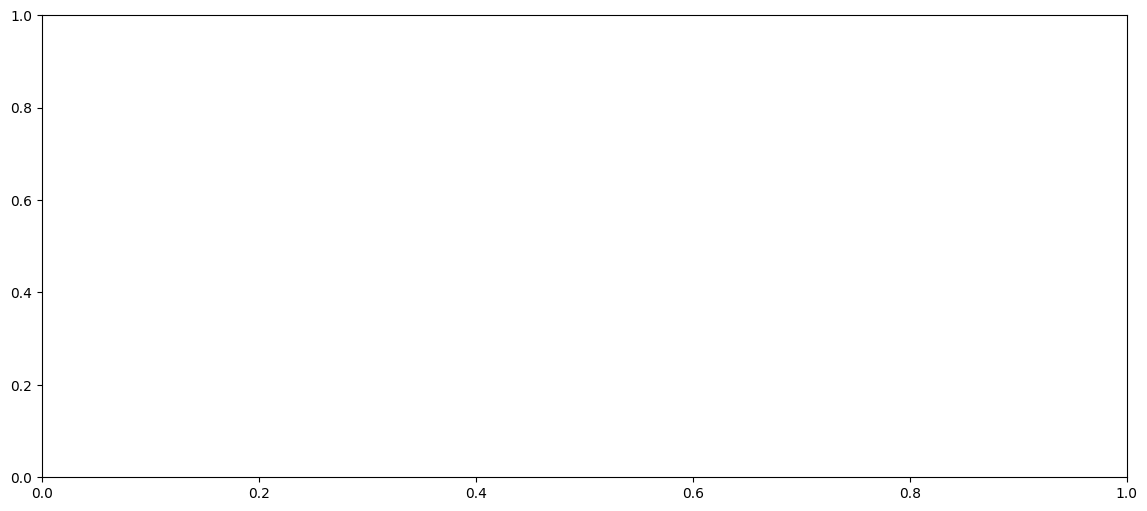

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

# Current FOMC curve
meeting_dates = implied_df["effective_date"]
rates = implied_df["best_implied"] * 100  # convert to percentage

ax.plot(meeting_dates, rates, marker="o", color="#4C78A8", linewidth=2, 
        markersize=8, label="Current FOMC Curve", zorder=3)

# Add current SOFR reference line
ax.axhline(CURRENT_SOFR * 100, color="red", linestyle="--", alpha=0.5, 
           linewidth=1.5, label=f"Current SOFR ({CURRENT_SOFR*100:.2f}%)")

# Annotate each point with the meeting label
for _, row in implied_df.iterrows():
    if pd.notna(row["best_implied"]):
        ax.annotate(
            row["meeting_label"],
            (row["effective_date"], row["best_implied"] * 100),
            textcoords="offset points", xytext=(0, 12),
            fontsize=8, ha="center", color="#333",
        )

ax.set_title("FOMC Curve: Implied SOFR Rate per Meeting")
ax.set_ylabel("Implied Rate (%)")
ax.set_xlabel("Meeting Date")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Attempt to load historical FOMC curves from curve_store
# This provides the "1 week ago" and "1 month ago" comparison
try:
    from Caching.curve_store import CurveStore
    
    store = CurveStore()
    
    # Try to get curves from 1 week and 1 month ago
    comparison_dates = {
        "1 week ago": datetime.date.today() - datetime.timedelta(days=7),
        "1 month ago": datetime.date.today() - datetime.timedelta(days=30),
    }
    
    historical_curves = {}
    for label, as_of in comparison_dates.items():
        try:
            hist_curve = mdp.get_pricer(dict(curve_name=CURVE_NAME, timestamp=as_of))
            hist_rates = {}
            for _, row in fomc_df.iterrows():
                mlabel = row["meeting_label"]
                eff = row["effective_date"].date()
                mat = row["maturity_date"].date()
                if mat < as_of:
                    continue
                try:
                    q = IRSwapQuery(
                        curve=CURVE_NAME,
                        effective_date=eff,
                        maturity_date=mat,
                        value=IRSwapValue.RATE,
                    )
                    pkg, _ = q.resolve_package(pricer_or_curve=hist_curve)
                    hist_rates[mlabel] = hist_curve.fair_rate(pkg[0])
                except Exception:
                    pass
            if hist_rates:
                historical_curves[label] = pd.Series(hist_rates)
        except Exception:
            pass
    
    if historical_curves:
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Current curve
        ax.plot(meeting_dates, rates, marker="o", color="#4C78A8", linewidth=2, 
                markersize=8, label="Current", zorder=3)
        
        # Historical curves
        hist_colors = {"1 week ago": "#F58518", "1 month ago": "#E45756"}
        for label, hist_s in historical_curves.items():
            hist_meetings = [m for m in implied_df["meeting_label"] if m in hist_s.index]
            hist_dates = implied_df[implied_df["meeting_label"].isin(hist_meetings)]["effective_date"]
            hist_vals = [hist_s[m] * 100 for m in hist_meetings]
            ax.plot(hist_dates, hist_vals, marker="s", color=hist_colors.get(label, "#999"),
                    linewidth=1.5, markersize=5, alpha=0.7, linestyle="--", label=label)
        
        ax.axhline(CURRENT_SOFR * 100, color="red", linestyle=":", alpha=0.3)
        ax.set_title("FOMC Curve: Current vs Historical")
        ax.set_ylabel("Implied Rate (%)")
        ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Repricing analysis
        if historical_curves:
            most_recent_hist = list(historical_curves.values())[0]
            reprice = {}
            for m in implied_df["meeting_label"]:
                if m in most_recent_hist.index and m in curve_implied:
                    reprice[m] = (curve_implied[m] - most_recent_hist[m]) * 10_000
            if reprice:
                reprice_s = pd.Series(reprice)
                biggest = reprice_s.abs().idxmax()
                print(f"Largest repricing: {biggest} ({reprice_s[biggest]:+.1f}bp)")
    else:
        print("Historical curves not available from curve_store. Skipping comparison.")

except ImportError:
    print("CurveStore not available. Skipping historical comparison.")

CurveStore not available. Skipping historical comparison.


## 7. FOMC Calendar Spreads (Meeting-to-Meeting)

Calendar spread = implied rate difference between consecutive meetings.  
`spread(N, N+1) = implied(N+1) - implied(N)`

Positive = market expects a hike at meeting N+1 relative to N.  
Negative = market expects a cut at meeting N+1.  
These isolate the expected policy change at a single meeting.

In [15]:
# Compute calendar spreads between consecutive meetings
spreads = []
for i in range(len(implied_df) - 1):
    curr = implied_df.iloc[i]
    nxt = implied_df.iloc[i + 1]
    
    curr_rate = curr["best_implied"]
    nxt_rate = nxt["best_implied"]
    
    if pd.notna(curr_rate) and pd.notna(nxt_rate):
        spread_bps = (nxt_rate - curr_rate) * 10_000
        spreads.append({
            "spread_label": f"{curr['meeting_label']} / {nxt['meeting_label']}",
            "front_meeting": curr["meeting_label"],
            "back_meeting": nxt["meeting_label"],
            "front_rate": curr_rate,
            "back_rate": nxt_rate,
            "spread_bps": spread_bps,
            "back_eff_date": nxt["effective_date"],
        })

spread_df = pd.DataFrame(spreads)

if not spread_df.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ["#E45756" if s < 0 else "#54A24B" for s in spread_df["spread_bps"]]
    bars = ax.bar(range(len(spread_df)), spread_df["spread_bps"], color=colors, alpha=0.8)
    ax.set_xticks(range(len(spread_df)))
    ax.set_xticklabels(spread_df["spread_label"], rotation=45, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("Spread (bps)")
    ax.set_title("FOMC Calendar Spreads: Meeting-to-Meeting Implied Rate Change")
    
    # Annotate values
    for i, (_, row) in enumerate(spread_df.iterrows()):
        ax.annotate(f"{row['spread_bps']:+.1f}", (i, row["spread_bps"]),
                     textcoords="offset points", xytext=(0, 8 if row["spread_bps"] >= 0 else -15),
                     ha="center", fontsize=8, fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    most_dovish = spread_df.loc[spread_df["spread_bps"].idxmin()]
    most_hawkish = spread_df.loc[spread_df["spread_bps"].idxmax()]
    print(f"Most dovish spread: {most_dovish['spread_label']} ({most_dovish['spread_bps']:+.1f}bp)")
    print(f"Most hawkish spread: {most_hawkish['spread_label']} ({most_hawkish['spread_bps']:+.1f}bp)")
    print(f"\nFull Calendar Spread Table:")
    display(spread_df[["spread_label", "front_rate", "back_rate", "spread_bps"]].round(4))
else:
    print("Insufficient data for calendar spread calculation.")

NameError: name 'implied_df' is not defined

## 8. Summary Dashboard
Key metrics at a glance for the trading desk.

In [16]:
print("=" * 70)
print("FOMC-DATED SWAP ANALYTICS SUMMARY")
print("=" * 70)
print(f"Data period: {START.date()} to {END.date()}")
print(f"Current SOFR: {CURRENT_SOFR*100:.2f}%")
print()

print("--- Flow ---")
n_fomc = len(fomc_trades)
print(f"Total FOMC-dated trades: {n_fomc:,}")
if n_fomc > 0:
    print(f"Total DV01: {sdr.format_dv01(fomc_trades['dv01'].sum())}")
    n_all = max(len(df), 1)
    print(f"Share of all trades: {n_fomc/n_all*100:.2f}%")
    print(f"Meetings with activity: {fomc_trades['meeting_label'].nunique()}")
    if 'meeting_dv01' in dir() and not meeting_dv01.empty:
        top_meeting = meeting_dv01["total_dv01"].idxmax()
        print(f"Busiest meeting: {top_meeting}")
else:
    print("(No SDR trade data available)")
print()

print("--- Implied Rates ---")
if not implied_df.empty:
    next_meeting = implied_df.iloc[0]
    print(f"Next meeting ({next_meeting['meeting_label']}): {next_meeting['best_implied']*100:.3f}% implied")
    print(f"  Implied move: {next_meeting['implied_move_bps']:+.1f}bp")
    print(f"  P(25bp cut): {next_meeting['p_cut_25bp']:.0f}%")
    
    total_cuts_val = implied_df["cumulative_cuts_25bp"].iloc[-1]
    through_label = implied_df["meeting_label"].iloc[-1]
    print(f"\nCumulative easing through {through_label}: {total_cuts_val:.1f} cuts ({total_cuts_val*25:.0f}bp)")

if 'spread_df' in dir() and not spread_df.empty:
    print(f"\nBiggest individual meeting move expected: {most_dovish['spread_label']} ({most_dovish['spread_bps']:+.1f}bp)")
print("=" * 70)

FOMC-DATED SWAP ANALYTICS SUMMARY


NameError: name 'START' is not defined